In [1]:
   import pandas as pd
   import matplotlib.pyplot as plt
   import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/KaggleV2-May-2016.csv")
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
df.shape

(110527, 14)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 11.8 MB


In [5]:
df = df.rename(columns={
    "PatientId": "patient_id",
    "AppointmentID": "appointment_id",
    "Gender": "gender",
    "ScheduledDay": "scheduled_day",
    "AppointmentDay": "appointment_day",
    "Age": "age",
    "Neighbourhood": "neighbourhood",
    "Scholarship": "scholarship",
    "Hipertension": "hypertension",
    "Diabetes": "diabetes",
    "Alcoholism": "alcoholism",
    "Handcap": "handicap",
    "SMS_received": "sms_received",
    "No-show": "no_show",
})
df.columns

Index(['patient_id', 'appointment_id', 'gender', 'scheduled_day',
       'appointment_day', 'age', 'neighbourhood', 'scholarship',
       'hypertension', 'diabetes', 'alcoholism', 'handicap', 'sms_received',
       'no_show'],
      dtype='str')

In [6]:
df["absent"] = (df["no_show"] == "Yes").astype(int)
df = df.drop(columns="no_show")
df["absent"].value_counts()

absent
0    88208
1    22319
Name: count, dtype: int64

In [7]:
df["scheduled_day"] = pd.to_datetime(df["scheduled_day"])
df["appointment_day"] = pd.to_datetime(df["appointment_day"])
df["patient_id"] = df["patient_id"].astype("int64")
df.dtypes

patient_id                       int64
appointment_id                   int64
gender                             str
scheduled_day      datetime64[us, UTC]
appointment_day    datetime64[us, UTC]
age                              int64
neighbourhood                      str
scholarship                      int64
hypertension                     int64
diabetes                         int64
alcoholism                       int64
handicap                         int64
sms_received                     int64
absent                           int64
dtype: object

In [8]:
df["absent"].mean()

np.float64(0.20193255946510807)

In [9]:
df["delai_jours"] = (
    df["appointment_day"].dt.normalize() - df["scheduled_day"].dt.normalize()
).dt.days
print(df["delai_jours"].describe())
print("Délais négatifs :", (df["delai_jours"] < 0).sum())

count    110527.000000
mean         10.183702
std          15.254996
min          -6.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: delai_jours, dtype: float64
Délais négatifs : 5


In [10]:
nb_avant = len(df)
df = df[(df["age"] >= 0) & (df["delai_jours"] >= 0)]
print(nb_avant - len(df), "lignes supprimées")
print("Il reste", len(df), "rendez-vous")

6 lignes supprimées
Il reste 110521 rendez-vous


Les lignes avec un âge négatif ou un délai négatif sont des erreurs de saisie. Elles ont été supprimées car elles sont très peu nombreuses et impossibles à corriger.

In [11]:
#regrouper les délais en tranches
df["tranche_delai"] = pd.cut(
    df["delai_jours"],
    bins=[-1, 0, 3, 14, 1000],
    labels=["Jour même", "1 à 3 jours", "4 à 14 jours", "15 jours et +"]
)
df["tranche_delai"].value_counts()

tranche_delai
Jour même        38562
4 à 14 jours     29535
15 jours et +    27749
1 à 3 jours      14675
Name: count, dtype: int64

tranche_delai
Jour même        0.046471
1 à 3 jours      0.228893
4 à 14 jours     0.273472
15 jours et +    0.327435
Name: absent, dtype: float64


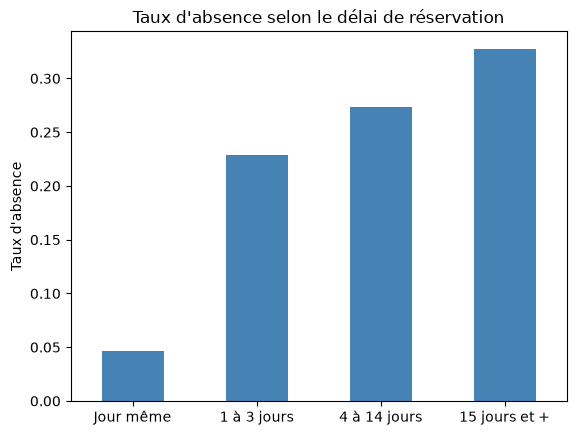

In [12]:
#calculer le taux d'absence par tranche et l'afficher
taux_delai = df.groupby("tranche_delai", observed=True)["absent"].mean()
print(taux_delai)

taux_delai.plot(kind="bar", color="steelblue")
plt.title("Taux d'absence selon le délai de réservation")
plt.ylabel("Taux d'absence")
plt.xlabel("")
plt.xticks(rotation=0)
plt.show()

          nb_rdv  taux_absence
Lundi      22713      0.206446
Mardi      25638      0.200874
Mercredi   25866      0.196861
Jeudi      17246      0.193494
Vendredi   19019      0.212261
Samedi        39      0.230769


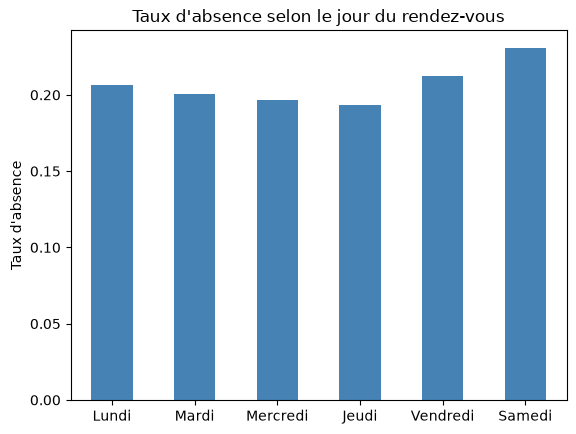

In [13]:
#jour de la semaine 
jours = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]
df["jour_semaine"] = df["appointment_day"].dt.dayofweek

resume_jour = df.groupby("jour_semaine").agg(
    nb_rdv=("absent", "count"),
    taux_absence=("absent", "mean")
)
resume_jour.index = [jours[i] for i in resume_jour.index]
print(resume_jour)

resume_jour["taux_absence"].plot(kind="bar", color="steelblue")
plt.title("Taux d'absence selon le jour du rendez-vous")
plt.ylabel("Taux d'absence")
plt.xticks(rotation=0)
plt.show()